(plotting_showcase)=

# Core plotting features

Choose a plot for the question you want to answer. An embedding shows where cells sit in a
UMAP or t-SNE layout; coloring it by a cluster, a gene, or a cell field reveals patterns in that
layout. Dot plots and matrix plots summarize marker expression across groups, while distribution
plots reveal variation within a group that an average can hide.

CyteArc also provides plots for cluster relationships, modality weights, pseudotime, reference
mapping, and comparisons between samples. This tutorial starts with the common views, then adds
ways to focus on groups, compose panels, and summarize large datasets as pixels. The
[plotting API reference](/api/plotting.html) describes the full set of options.

## Open the example data

This pancreas dataset contains an analysis saved as `docs_default`. Its live `clusters` metadata
column holds the published cell-type annotations. We use `CellField` to name that column
explicitly and avoid confusing it with the run's computed clusters.

In [1]:
# Manage local file and directory paths.
from pathlib import Path

# Arrange and save Matplotlib figures.
import matplotlib.pyplot as plt

# Open count stores and run CyteArc analyses.
import cytearc

# Use CyteArc plotting options and diagnostics.
import cytearc.plotting as splt

# Keep routine logs and progress bars out of the results.
cytearc.configure_output(level="WARNING", progress=False)

# Download the prepared example store.
dataset = cytearc.cytebase.connect("cytearc_docs").download_dataset(
    "bastidas-ponce_4K_pancreas-d15_rnaseq",
    destination="cytearc_datasets",
    zarr=True,
)

# Open the count store for this analysis.
ds = cytearc.DataStore(f"{dataset}/data.zarr", nthreads=4)

# Open the saved analysis and its exact results.
run = ds.pipeline.open(label="docs_default")

# Keep the saved UMAP coordinates for the figures.
layout = run["umap"]

# Use the published cell-type metadata for colors and groups.
cell_types = splt.CellField("clusters", label="cell type")

# Inspect the opened store's cells and features.
ds

DataStore has 3696 (3696) cells with 1 assays: RNA
   Cell metadata:
            'I', 'ids', 'names', 'G2M_score', 'RNA_UMAP1', 
            'RNA_UMAP2', 'RNA_clusters', 'RNA_leiden_cluster', 'RNA_nCounts', 'RNA_nFeatures', 
            'RNA_percentMito', 'RNA_percentRibo', 'S_score', 'clusters', 'clusters_coarse'
   RNA assay has 27998 features and following metadata:
            'I', 'ids', 'names', 'dropOuts', 'highly_variable_genes', 
            'nCells'

Started: 2026-10-08T11:03:28.832206Z | Wall time: 18.086 s

## Color an embedding

Pass the saved layout and the values you want to show. Here the colors identify cell types.

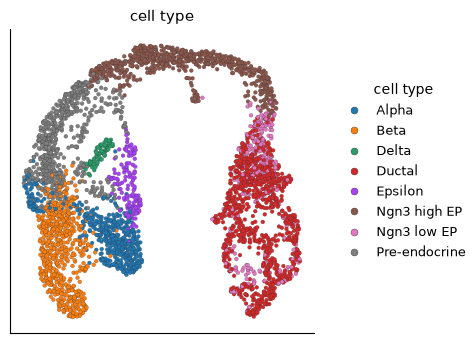

Started: 2026-10-08T11:03:46.931922Z | Wall time: 1.320 s

In [2]:
# Color the UMAP by the published cell-type annotations.
ds.plots.embedding(layout=layout, color_by=cell_types)

A gene name colors cells by expression. A list of genes produces several panels:

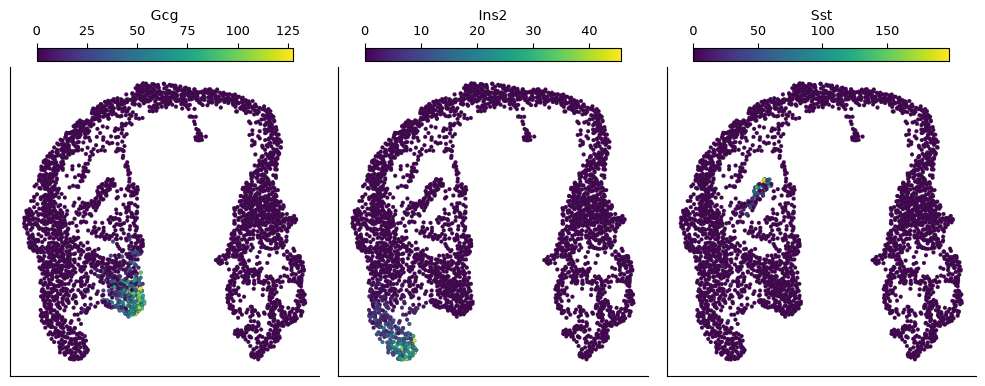

Started: 2026-10-08T11:03:48.260952Z | Wall time: 3.028 s

In [3]:
# Compare Gcg, Ins2, and Sst expression on separate UMAP panels.
ds.plots.embedding(layout=layout, color_by=["Gcg", "Ins2", "Sst"])

Compare the expression patterns with the annotated populations. The plot uses assay-normalized
expression by default. If a few high values hide the rest, adjust the display scale as shown below.

### Make expression easier to see

Use these display changes when the default gene panels are hard to read:

- `NormalizationSpec(transform="log1p")` compresses the expression scale.
- `sort_values=True` draws high-expressing cells last so other cells do not cover them.
- `ColorScale(quantiles=(0.0, 0.99))` caps the color range at the 99th percentile.

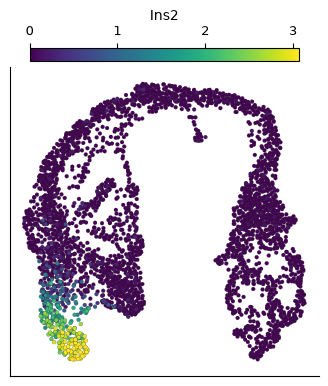

Started: 2026-10-08T11:03:51.302579Z | Wall time: 1.027 s

In [4]:
# Show log-transformed Ins2 expression with the upper color range clipped.
ds.plots.embedding(
    layout=layout,
    color_by="Ins2",
    normalization=splt.NormalizationSpec(transform="log1p"),
    sort_values=True,
    color_scale=splt.ColorScale(quantiles=(0.0, 0.99)),
)

These choices affect the display, not the saved counts. Clipping the color range makes all values
above the limit share the same color, so report that choice when presenting a figure.

## Summarize markers across groups

A dotplot shows two summaries: color is mean expression, and dot size is the fraction of measured
cells whose expression exceeds `expression_cutoff` (zero by default). A large dot with a low
mean indicates widespread low expression; a small dot with a high mean indicates strong
expression in a minority of cells. The mean includes cells with zero expression.

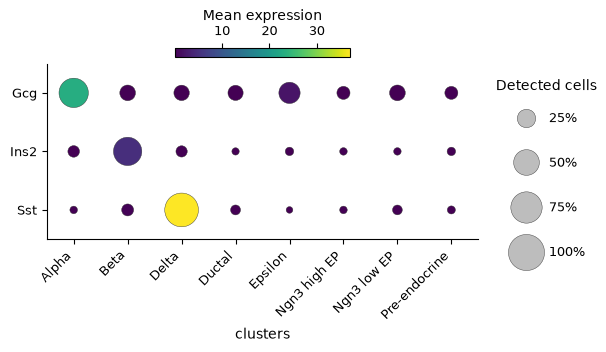

Started: 2026-10-08T11:03:52.333592Z | Wall time: 1.576 s

In [5]:
# Compare marker expression and detection across the selected groups.
ds.plots.dotplot(
    features=["Gcg", "Ins2", "Sst"],
    group_by="clusters",
)

A matrixplot shows mean expression as a heatmap:

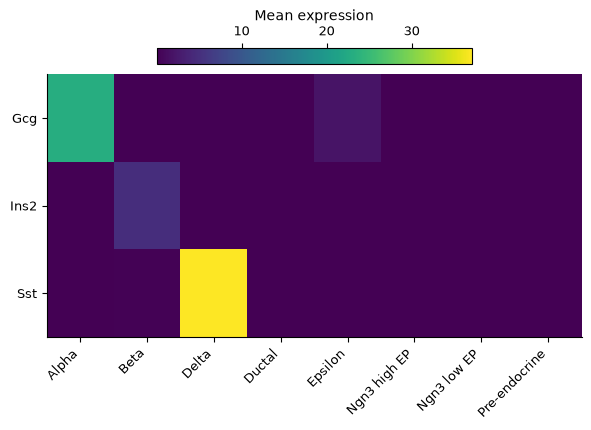

Started: 2026-10-08T11:03:53.912099Z | Wall time: 0.747 s

In [6]:
# Compare mean marker expression across cell types.
ds.plots.matrixplot(
    features=["Gcg", "Ins2", "Sst"],
    group_by="clusters",
)

For `matrixplot`, use `value="fraction"` to show the fraction of measured cells above
`expression_cutoff` instead of mean expression. Both plots keep the gene order you supply; `group_order` controls the order of
the displayed groups.

For `matrixplot`, `cluster_groups=True` groups similar profiles together by hierarchical
clustering and adds a dendrogram. This can reveal relationships that a fixed group order hides.
`dotplot` does not take this option, so set its order with `group_order`.

## Inspect distributions

During QC, count depth and detected-gene distributions can reveal cells that differ sharply
from the rest of their group. Use distributions to see this variation within groups rather than
relying only on an average.

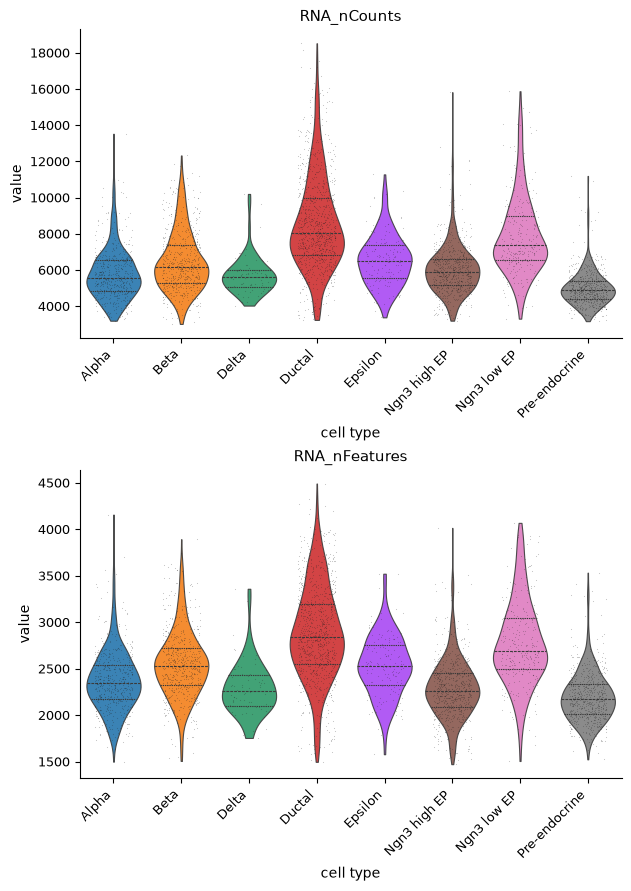

Started: 2026-10-08T11:03:54.662385Z | Wall time: 0.960 s

In [7]:
# Compare count depth and detected genes across annotated cell types.
ds.plots.distribution(
    keys=["RNA_nCounts", "RNA_nFeatures"],
    grouping=cell_types,
)

The default is a violin plot. `kind="box"`, `kind="hist"`, and `kind="ecdf"` provide other views.
Use `groups=["Alpha", "Beta", "Delta"]` to focus on those cell types.
See [](quality_control.ipynb) for choosing thresholds from QC distributions.

Stacked violins compare several marker distributions across selected cell types. `grouping`
chooses the labels used to divide cells, while `groups` limits which labeled populations appear:

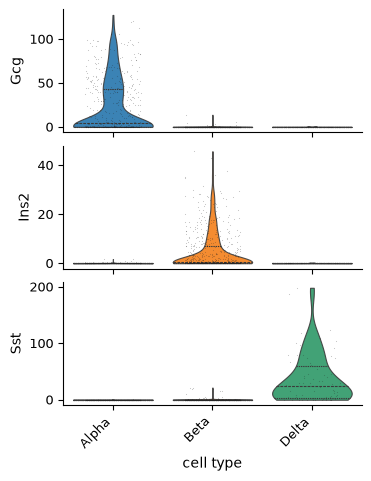

Started: 2026-10-08T11:03:55.626130Z | Wall time: 1.101 s

In [8]:
# Compare three endocrine markers with stacked violin plots.
ds.plots.distribution(
    keys=["Gcg", "Ins2", "Sst"],
    grouping=cell_types,
    groups=["Alpha", "Beta", "Delta"],
    kind="stacked_violin",
)

For a single gene, a violin plot gives more space to inspect its distribution in each cell type.
Here, compare Sst in the annotated Delta population with the other populations:

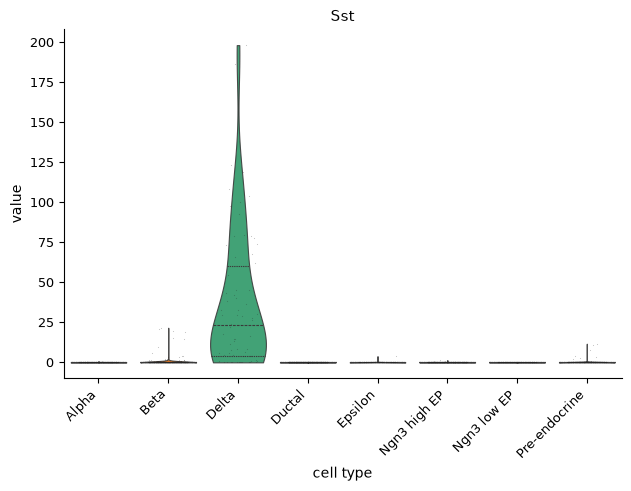

Started: 2026-10-08T11:03:56.730942Z | Wall time: 0.761 s

In [9]:
# Compare Sst expression distributions across the annotated cell types.
ds.plots.distribution(keys=["Sst"], grouping=cell_types, kind="violin")

Changing `kind` to `"box"` or `"hist"` shows the same selected values in another form.

## Save a figure

Plots display automatically in a notebook. Set `show=False` when you want to save or change the
figure first. The returned `PlotResult` provides `save` and `close`.

In [10]:
# Choose a persistent directory for figures.
output_directory = Path("figures")

# Create the output directory if needed.
output_directory.mkdir(exist_ok=True)

# Create the figure without displaying it yet.
result = ds.plots.embedding(layout=layout, color_by=cell_types, show=False)

# Choose the filename for the cell-type figure.
figure_path = output_directory / "pancreas_cell_types.png"

# Save the figure to the chosen file.
result.save(figure_path)

# Close the figure after saving it.
result.close()

# Confirm the written filename and its size in bytes.
{"file": str(figure_path), "bytes": figure_path.stat().st_size}

{'file': 'figures/pancreas_cell_types.png', 'bytes': 201721}

Started: 2026-10-08T11:03:57.496131Z | Wall time: 0.545 s

The file stays in `figures` after the notebook closes. Change the extension to save PDF, SVG, or
TIFF. For publication, `dpi=300` controls raster resolution and `exact_size=True` preserves the
figure's physical dimensions. Add `provenance_sidecar=True` when you also need a JSON record of
the selection and plot settings.

## Focus on selected groups

Facets show the same layout in separate panels. Here each panel contains one annotated cell type,
colored by Ins2 expression. The panels use a shared expression scale.

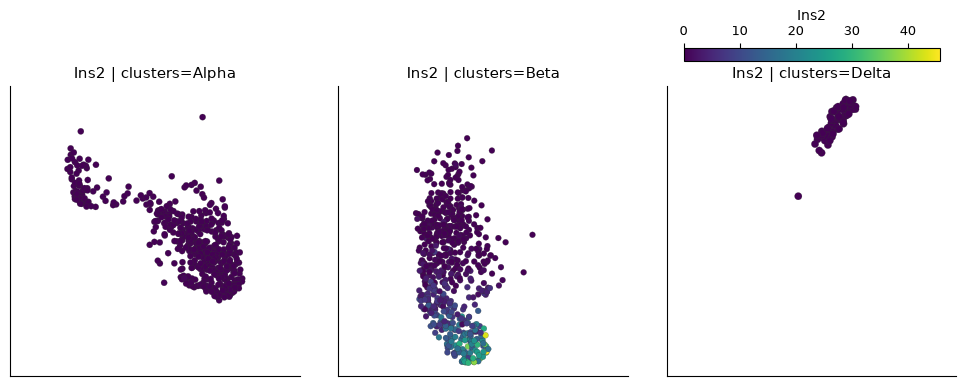

Started: 2026-10-08T11:03:58.044423Z | Wall time: 0.738 s

In [11]:
# Show Ins2 expression separately in Alpha, Beta, and Delta cells.
ds.plots.embedding(
    layout=layout,
    color_by="Ins2",
    facet_by=cell_types.key,
    groups=["Alpha", "Beta", "Delta"],
)

A highlight keeps the other cells visible for context:

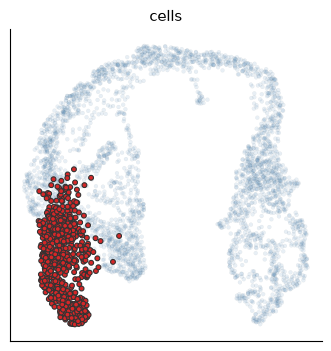

Started: 2026-10-08T11:03:58.784644Z | Wall time: 0.372 s

In [12]:
# Highlight Beta cells while retaining the other cells for context.
ds.plots.embedding(
    layout=layout,
    color_by=None,
    highlight=splt.Highlight(by=cell_types.key, groups=("Beta",)),
)

For real replicated studies, `sample_by` summarizes samples. Composition plots can compare cell
type fractions across samples, and a `StudyDesign` can connect paired observations.
See [](condition_comparisons.ipynb) for examples with actual study metadata.

## Compose panels and choose a style

Pass Matplotlib axes as `target` when you need control over a figure's arrangement:

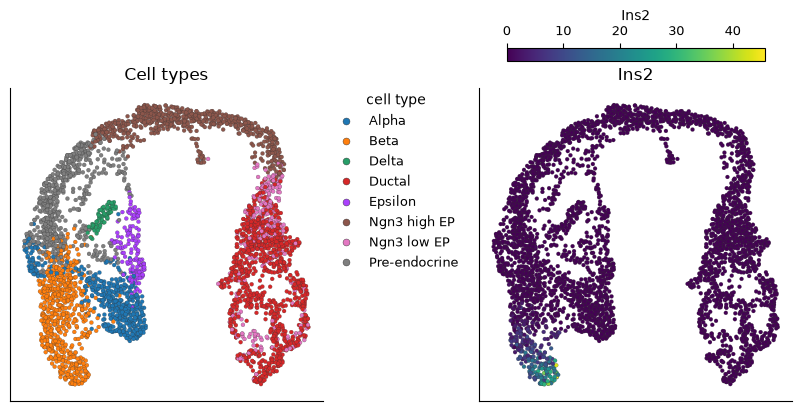

Started: 2026-10-08T11:03:59.159519Z | Wall time: 1.503 s

In [13]:
# Create axes for the comparison panels.
figure, axes = plt.subplots(1, 2, figsize=(8, 4), layout="constrained")

# Draw each result on its comparison axes.
for axis, field, title in zip(
    axes, (cell_types, "Ins2"), ("Cell types", "Ins2"), strict=True
):

    # Draw cell-type labels or Ins2 expression in the corresponding panel.
    ds.plots.embedding(
        layout=layout,
        color_by=field,
        target=axis,
        show_titles=False,
        show=False,
    )

    # Label the panel with the result it shows.
    axis.set_title(title)

# Display the completed comparison figure.
figure

The figure belongs to you because you created its axes. Save it with Matplotlib and close it
afterward:

In [14]:
# Choose the filename for the composed figure.
panel_path = output_directory / "pancreas_panels.pdf"

# Save the figure to the chosen file.
figure.savefig(panel_path)

# Close the figure after saving it.
plt.close(figure)

# Confirm the written filename and its size in bytes.
{"file": str(panel_path), "bytes": panel_path.stat().st_size}

{'file': 'figures/pancreas_panels.pdf', 'bytes': 1302703}

Started: 2026-10-08T11:04:00.666399Z | Wall time: 2.044 s

CyteArc's default theme suits notebooks. Use `theme="paper"` for smaller labels or
`theme="dark"` for a dark background. Leave point sizes and legend placement at their defaults
unless they obscure the data. `legend_loc="on_data"` puts category labels on the embedding:

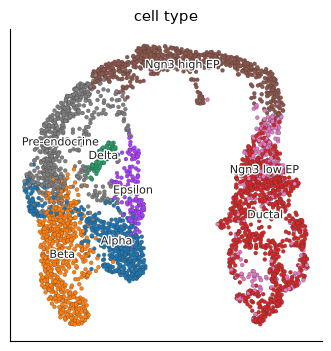

Started: 2026-10-08T11:04:02.714115Z | Wall time: 0.500 s

In [15]:
# Place cell-type labels directly on their populations in the UMAP.
ds.plots.embedding(layout=layout, color_by=cell_types, legend_loc="on_data")

Compare this with the first embedding's separate legend. Labels on the data can make a small
number of separated populations easier to find, but may obscure overlapping populations.
For composed figures that need a combined provenance record, see `cytearc.plotting.compose_results`
in the [Plotting API reference](/api/plotting.html) reference.

## Plot large datasets as pixels

`embedding_raster` summarizes a continuous metadata column into pixels. It avoids loading the
full column into memory and is useful when a scatter plot has too many overlapping points.

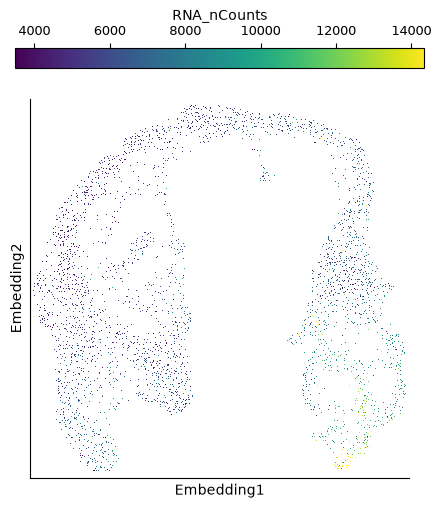

Started: 2026-10-08T11:04:03.218313Z | Wall time: 0.517 s

In [16]:
# Summarize count depth into pixels on the embedding.
ds.plots.embedding_raster(layout=layout, color_by="RNA_nCounts")

This small dataset illustrates the call; the memory benefit matters on larger datasets.
Use `embedding` for gene expression. Empty raster pixels are white by default.

## Where to find analysis diagnostics

Keep diagnostics near the analysis they help evaluate:

- [](feature_selection.ipynb): use the mean-variance plot to inspect which genes enter the analysis.
- [](graph_construction.ipynb): inspect graph degree and edge weights before interpreting clusters.
- [](dimensionality_reduction.ipynb): compare PCA components and layout choices.
- [](clustering.ipynb): inspect membership strength and relationships between clusters.
- [](annotation.ipynb): compare marker heatmaps and cell-type evidence before accepting a label.

Before interpreting a figure, check its cells, grouping, and expression scale. Add a panel when
it answers a new question, rather than only changing the decoration.